In [1]:
#Importing Important Stuff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stat 
import math 
from pylab import *
import os
import fmEphys as fme
from tqdm import tqdm
#import seaborn as sns
import sklearn
from sklearn.neighbors import KernelDensity
import pickle

import sys
sys.path.append(r"C:\Users\Niell Lab\Documents\GitHub\freely-moving-saccades")
import saccadeAnalysis as sacc


def norm_psth(psth_pre, psth_post):
    kernel_size = 25
    kernel = np.ones(kernel_size) / kernel_size

    #psth_pre = np.convolve(psth_pre, kernel, mode='same')
    #psth_post = np.convolve(psth_post, kernel, mode='same')
    
    #subtract off baseline value
    baselined_psth_pre = psth_pre - np.nanmean(psth_pre[200:950].astype(float))
    baselined_psth_post = psth_post - np.nanmean(psth_post[200:950].astype(float))

    #find max FR before and after injection
    mx_pre = np.nanmax(np.abs(baselined_psth_pre[750:1500]))
    mx_post = np.nanmax(np.abs(baselined_psth_post[750:1500]))
    Mx = np.nanmax([mx_pre,mx_post])

    #normalize psth to max
    norm_psth_pre = baselined_psth_pre/Mx
    norm_psth_post = baselined_psth_post/Mx

    return norm_psth_pre, norm_psth_post 

def calc_PSTH(spikeT, eventT, bandwidth=10, resample_size=1, edgedrop=15, win=1000, num_events=None):
    """
    calcualtes for a single cell at a time

    bandwidth (in msec)
    resample_size (msec)
    edgedrop (msec to drop at the start and end of the window so eliminate artifacts of filtering)
    win = 1000msec before and after
    """

    # Some conversions
    bandwidth = bandwidth / 1000
    resample_size = resample_size / 1000
    win = win / 1000
    edgedrop = edgedrop / 1000
    edgedrop_ind = int(edgedrop / resample_size)

    # Setup time bins. The bins of the returned PSTH will be -`win` msec to +`win` msec
    # with `resame_size` msec bins, where 0 is the time of the event. Because of edge effects
    # from the gaussian filter, we'll calculate the PSTH with an extra `edgedrop` msec at the
    # start and end so that the edges of the PSTH can be dropped without losing timepoints
    # we care about.
    bins = np.arange(-win-edgedrop, win+edgedrop+resample_size, resample_size)

    # if there is only one event time (i.e. if it's an int for all spikes like eventT=np.array(0)
    if np.size(eventT)>1:

        # Get the timestamps of spikes relative to events in `eventT`
        sps = []
        for i, t in enumerate(eventT):
            sp = spikeT-t
            # Only keep spikes in this window
            sp = sp[(sp <= (win+edgedrop)) & (sp >= (-win-edgedrop))]
            sps.extend(sp)
        num_events = np.size(eventT)
    else:
        sps = eventT.copy().flatten()
    
    # If `win` is 1000 msec, values in `sps` will fall between -1 and 1, since only spikes
    # that fall before or after the event by 1 second are included.
    # (Because of `edge_drop`, values can be a bit beyond `win` but those will be eliminated before
    # the PSTH is returned.
    sps = np.array(sps)

    # Calculate the PSTH using Kernel Density Estimation
    kernel = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(sps[:, np.newaxis])
    density = kernel.score_samples(bins[:, np.newaxis])

    # Here, `density` is a probability function that sums to 1. We want it in sp/sec.
    # We need to multiply by the # spikes to get the spike count per point. Then,
    # we divide by the number of events so that we get teh rate per event.
    psth = np.exp(density) * (np.size(sps) / num_events)

    # Drop the extra time at the start and end of the window, since it will have
    # edge effects from the gaussian filter. After dropping this, it will be the
    # size set by `win`, so no important timepoints are actually lost here.
    psth = psth[edgedrop_ind:-edgedrop_ind]

    return psth

def calc_std_modidx(psth,thresh):
 
    psth = psth.astype(float)
    psth = psth - np.nanmean(psth[100:750])

    std_thresh = np.nanstd(psth[100:750]*thresh)
    
    if np.nanmax((np.abs(psth[900:1500])-std_thresh)) > 0:
        mod = 1
    else:
        mod = 0 
    return mod
    

def calc_fr_modidx(psth,thresh):

    psth = psth.astype(float)
    psth = psth - np.nanmean(psth[100:750])

    if np.nanmax(np.abs(psth[900:1500])) > thresh:
        mod = 1
    else:
        mod = 0
    return mod

# Function to plot mean and standard deviation for each group
def plot_group_mean_std(group_mean, group_std, color, label):
    plt.plot(group_mean, c=color, label=label, linewidth=3)
    plt.fill_between(range(len(group_mean)), group_mean - group_std, group_mean + group_std, color=color, alpha=0.3)



def norm_psth(psth_pre, psth_post):
    kernel_size = 25
    kernel = np.ones(kernel_size) / kernel_size

    #psth_pre = np.convolve(psth_pre, kernel, mode='same')
    #psth_post = np.convolve(psth_post, kernel, mode='same')
    
    #subtract off baseline value
    baselined_psth_pre = psth_pre - np.nanmean(psth_pre[200:800].astype(float))
    baselined_psth_post = psth_post - np.nanmean(psth_post[200:800].astype(float))

    #find max FR before and after injection
    mx_pre = np.nanmax(np.abs(baselined_psth_pre[750:1500]))
    mx_post = np.nanmax(np.abs(baselined_psth_post[750:1500]))
    Mx = np.nanmax([mx_pre,mx_post])

    #normalize psth to max
    norm_psth_pre = baselined_psth_pre/Mx
    norm_psth_post = baselined_psth_post/Mx

    return norm_psth_pre, norm_psth_post 

def jitter(c, sz, maxdist=0.25):
    """ Jitter x values.

    This is useful for scatter plots of categorical data,
    when the distribution along y is more clear when the
    x position of that category is jittered slightly.

    Parameters
    ----------
    c : int or float
        Center position of the data.
    sz : int
        Number of data points.
    maxdist : float
        Maximum distance that a value can be jittered
        from their center point, `c`.

    Returns
    -------
    j_x : np.array
        Jittered x values in a 1D array of length `sz`.

    """

    j_x = np.ones(sz) + np.random.uniform(c-maxdist, c+maxdist, sz)

    return j_x

Loading DLC 2.3.0...


In [3]:
DOI_Data = pd.read_hdf(r"D:\PrePostDOI\DOI Datasets\AllMice_GazeShifts_DOI.h5")
Saline_Data = pd.read_hdf(r"D:\PrePostDOI\Saline Datasets\AllMice_GazeShift_Saline.h5")

In [4]:
DOI_NotContaminted = np.where(DOI_Data.loc[:,'Contamination_Index']<=30)
Saline_NotContaminted = np.where(Saline_Data.loc[:,'Contamination_Index']<=30)

DOI_Data = DOI_Data.iloc[DOI_NotContaminted]
Saline_Data = Saline_Data.iloc[Saline_NotContaminted]
print(len(DOI_Data))
print(len(Saline_Data))

KeyError: 'Contamination_Index'

In [5]:
#loading in datasets
#DOI_Data = pd.read_hdf(r"D:\PrePostDOI\DOI Datasets\AllMice_GazeShifts_DOI.h5")
#Saline_Data = pd.read_hdf(r"D:\PrePostDOI\Saline Datasets\AllMice_GazeShifts_Saline.h5")

Mouse = np.stack(DOI_Data.loc[:,'Mouse'])
#####################
#pulling preferred gaze 
PreDOI_Gaze = np.stack(DOI_Data.loc[:,'Pre_Pref_Gaze'])
PostDOI_Gaze = np.stack(DOI_Data.loc[:,'Post_Pref_Gaze'])

PreSaline_Gaze = np.stack(Saline_Data.loc[:,'Pre_Pref_Gaze'])
PostSaline_Gaze = np.stack(Saline_Data.loc[:,'Post_Pref_Gaze'])

#lightly filtering
kernel_size = 25
kernel = np.ones(kernel_size) / kernel_size

PreDOI_Gaze_filt = PreDOI_Gaze.copy()
PostDOI_Gaze_filt = PostDOI_Gaze.copy()
PreSaline_Gaze_filt = PreSaline_Gaze.copy()
PostSaline_Gaze_filt = PostSaline_Gaze.copy()

#finding responsive neurons and making responsivitiy masks
PreDOI_Responsive = np.zeros(len(PreDOI_Gaze))
PostDOI_Responsive =  np.zeros(len(PreDOI_Gaze))

for ii in range(0,len(PreDOI_Gaze)):
    PreDOI_Gaze_filt[ii,:] =  np.convolve(PreDOI_Gaze[ii,:], kernel, mode = 'same')
    PostDOI_Gaze_filt[ii,:] = np.convolve(PostDOI_Gaze[ii,:], kernel, mode = 'same')

    PreDOI_FR_Threshold = calc_fr_modidx(PreDOI_Gaze_filt[ii,:], 1)
    PreDOI_STD_Threshold = calc_std_modidx(PreDOI_Gaze_filt[ii,:], 3.5)

    PostDOI_FR_Threshold = calc_fr_modidx(PostDOI_Gaze_filt[ii,:], 1)
    PostDOI_STD_Threshold = calc_std_modidx(PostDOI_Gaze_filt[ii,:], 3.5)

    if (PreDOI_FR_Threshold == 1) & (PreDOI_STD_Threshold == 1):
        PreDOI_Responsive[ii] = 1

    if (PostDOI_FR_Threshold == 1) & (PostDOI_STD_Threshold == 1):
        PostDOI_Responsive[ii] = 1

PreSaline_Responsive = np.zeros(len(PreSaline_Gaze))
PostSaline_Responsive =  np.zeros(len(PreSaline_Gaze))

for ii in range(0,len(PreSaline_Gaze)):
    PreSaline_Gaze_filt[ii,:] =  np.convolve(PreSaline_Gaze[ii,:], kernel, mode = 'same')
    PostSaline_Gaze_filt[ii,:] = np.convolve(PostSaline_Gaze[ii,:], kernel, mode = 'same')

    PreSaline_FR_Threshold = calc_fr_modidx(PreSaline_Gaze_filt[ii,:], 1)
    PreSaline_STD_Threshold = calc_std_modidx(PreSaline_Gaze_filt[ii,:], 3.5)

    PostSaline_FR_Threshold = calc_fr_modidx(PostSaline_Gaze_filt[ii,:], 1)
    PostSaline_STD_Threshold = calc_std_modidx(PostSaline_Gaze_filt[ii,:], 3.5)

    if (PreSaline_FR_Threshold == 1) & (PreSaline_STD_Threshold == 1):
        PreSaline_Responsive[ii] = 1

    if (PostSaline_FR_Threshold == 1) & (PostSaline_STD_Threshold == 1):
        PostSaline_Responsive[ii] = 1

DOI_ResponsivetoBoth = PreDOI_Responsive + PostDOI_Responsive
DOI_ResponsivetoBoth[DOI_ResponsivetoBoth<2] = 0
DOI_ResponsivetoBoth[DOI_ResponsivetoBoth==2] = 1
DOI_ResponsivetoOne = PreDOI_Responsive + PostDOI_Responsive
DOI_ResponsivetoOne[DOI_ResponsivetoOne>0] = 1

Saline_ResponsivetoBoth = PreSaline_Responsive + PostSaline_Responsive
Saline_ResponsivetoBoth[Saline_ResponsivetoBoth<2] = 0
Saline_ResponsivetoBoth[Saline_ResponsivetoBoth==2] = 1
Saline_ResponsivetoOne = PreSaline_Responsive + PostSaline_Responsive
Saline_ResponsivetoOne[Saline_ResponsivetoOne>0] = 1

#Normalizing Gaze Shift Responses 
PreDOI_Baseline = np.nanmean(PreDOI_Gaze_filt[:,100:750],axis=1)
PostDOI_Baseline = np.nanmean(PostDOI_Gaze_filt[:,100:750],axis=1)
PreSaline_Baseline = np.nanmean(PreSaline_Gaze_filt[:,100:750],axis=1)
PostSaline_Baseline = np.nanmean(PostSaline_Gaze_filt[:,100:750],axis=1)

PreDOI_Gaze_Baselined = PreDOI_Gaze_filt - PreDOI_Baseline[:,None]
PostDOI_Gaze_Baselined = PostDOI_Gaze_filt - PostDOI_Baseline[:,None]
PreSaline_Gaze_Baselined = PreSaline_Gaze_filt - PreSaline_Baseline[:,None]
PostSaline_Gaze_Baselined = PostSaline_Gaze_filt - PostSaline_Baseline[:,None]

PreDOI_Max = np.nanmax(np.abs(PreDOI_Gaze_Baselined[:,900:1500]),axis=1)
PostDOI_Max = np.nanmax(np.abs(PostDOI_Gaze_Baselined[:,900:1500]),axis=1)
DOI_Max = np.nanmax([PreDOI_Max,PostDOI_Max],axis=0)
PreSaline_Max = np.nanmax(np.abs(PreSaline_Gaze_Baselined[:,900:1500]),axis=1)
PostSaline_Max = np.nanmax(np.abs(PostSaline_Gaze_Baselined[:,900:1500]),axis=1)
Saline_Max = np.nanmax([PreSaline_Max,PostSaline_Max],axis=0)

PreDOI_Gaze_Normalized = PreDOI_Gaze_Baselined/DOI_Max[:,None]
PostDOI_Gaze_Normalized = PostDOI_Gaze_Baselined/DOI_Max[:,None]
PreSaline_Gaze_Normalized = PreSaline_Gaze_Baselined/Saline_Max[:,None]
PostSaline_Gaze_Normalized = PostSaline_Gaze_Baselined/Saline_Max[:,None]

#Clustering Gaze Shift Responses 
km_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/KMeans_PSTH_model_062022.pickle'
pca_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/PCA_PSTH_model_062022.pickle'

with open(km_model_path, 'rb') as f:
    kmeans_model = pickle.load(f)
with open(pca_model_path, 'rb') as f:
    pca = pickle.load(f)

PreDOI_Max = np.nanmax(PreDOI_Gaze_filt[:,750:1250],axis=1)
PreDOI_Norm = PreDOI_Gaze_filt - np.nanmean(PreDOI_Gaze_filt[:,100:800],axis=1)[:,None]
PreDOI_Norm = PreDOI_Norm/PreDOI_Max[:,None]


PreDOI_Gaze_4Clustering = np.nan_to_num(PreDOI_Norm.copy(),copy=False)
PreDOI_Gaze_4Clustering[PreDOI_Responsive == 0] = np.zeros([2001])

proj = pca.transform(PreDOI_Gaze_4Clustering[:, 950:1300])
gproj = proj[:,:4]  
PreDOI_Labels = kmeans_model.predict(gproj)  
##
PostDOI_Max = np.nanmax(PostDOI_Gaze_filt[:,750:1250],axis=1)
PostDOI_Norm = PostDOI_Gaze_filt - np.nanmean(PostDOI_Gaze_filt[:,100:800],axis=1)[:,None]
PostDOI_Norm = PostDOI_Norm/PostDOI_Max[:,None]


PostDOI_Gaze_4Clustering = np.nan_to_num(PostDOI_Norm.copy(),copy=False)
PostDOI_Gaze_4Clustering[PostDOI_Responsive == 0] = np.zeros([2001])

proj = pca.transform(PostDOI_Gaze_4Clustering[:, 950:1300])
gproj = proj[:,:4]  
PostDOI_Labels = kmeans_model.predict(gproj)  
##
PreSaline_Max = np.nanmax(PreSaline_Gaze_filt[:,750:1250],axis=1)
PreSaline_Norm = PreSaline_Gaze_filt - np.nanmean(PreSaline_Gaze_filt[:,100:800],axis=1)[:,None]
PreSaline_Norm = PreSaline_Norm/PreSaline_Max[:,None]


PreSaline_Gaze_4Clustering = np.nan_to_num(PreSaline_Norm.copy(),copy=False)
PreSaline_Gaze_4Clustering[PreSaline_Responsive == 0] = np.zeros([2001])

proj = pca.transform(PreSaline_Gaze_4Clustering[:, 950:1300])
gproj = proj[:,:4]  
PreSaline_Labels = kmeans_model.predict(gproj)

##
PostSaline_Max = np.nanmax(PostSaline_Gaze_filt[:,750:1250],axis=1)
PostSaline_Norm = PostSaline_Gaze_filt - np.nanmean(PostSaline_Gaze_filt[:,100:800],axis=1)[:,None]
PostSaline_Norm = PostSaline_Norm/PostSaline_Max[:,None]


PostSaline_Gaze_4Clustering = np.nan_to_num(PostSaline_Norm.copy(),copy=False)
PostSaline_Gaze_4Clustering[PostSaline_Responsive == 0] = np.zeros([2001])

proj = pca.transform(PostSaline_Gaze_4Clustering[:, 950:1300])
gproj = proj[:,:4]  
PostSaline_Labels = kmeans_model.predict(gproj)

In [6]:
DOI_Change_Baseline = PostDOI_Baseline[PreDOI_Responsive.astype(bool)] - PreDOI_Baseline[PreDOI_Responsive.astype(bool)]
Saline_Change_Baseline = PostSaline_Baseline[PreSaline_Responsive.astype(bool)] - PreSaline_Baseline[PreSaline_Responsive.astype(bool)]

DOI_Change_Max = PostDOI_Max[PreDOI_Responsive.astype(bool)] - PreDOI_Max[PreDOI_Responsive.astype(bool)]
Saline_Change_Max = PostSaline_Max[PreSaline_Responsive.astype(bool)] - PreSaline_Max[PreSaline_Responsive.astype(bool)]

In [7]:
DOI_Change_Max_ModIDX = (PostDOI_Max[PreDOI_Responsive.astype(bool)] - PreDOI_Max[PreDOI_Responsive.astype(bool)])/(PostDOI_Max[PreDOI_Responsive.astype(bool)] + PreDOI_Max[PreDOI_Responsive.astype(bool)])
Saline_Change_Max_ModIDX = (PostSaline_Max[PreSaline_Responsive.astype(bool)] - PreSaline_Max[PreSaline_Responsive.astype(bool)])/(PostSaline_Max[PreSaline_Responsive.astype(bool)] + PreSaline_Max[PreSaline_Responsive.astype(bool)])

DOI_Change_Baseline_ModIDX = (PostDOI_Baseline[PreDOI_Responsive.astype(bool)] - PreDOI_Baseline[PreDOI_Responsive.astype(bool)])/(PostDOI_Baseline[PreDOI_Responsive.astype(bool)] + PreDOI_Baseline[PreDOI_Responsive.astype(bool)])
Saline_Change_Baseline_ModIDX = (PostSaline_Baseline[PreSaline_Responsive.astype(bool)] - PreSaline_Baseline[PreSaline_Responsive.astype(bool)])/(PostSaline_Baseline[PreSaline_Responsive.astype(bool)] + PreSaline_Baseline[PreSaline_Responsive.astype(bool)])

In [9]:
figpath = 'G:\My Drive\Science Files\Manuscripts\DOI Project\Figures\Fig 4 - Laminar Analysis'

In [8]:
DepthFromL5 = DOI_Data.loc[:,'Wn_depth_from_layer5']
DepthFromL5 = DepthFromL5[PreDOI_Responsive.astype(bool)]
PreDOI_Labels_Lim = PreDOI_Labels[PreDOI_Responsive.astype(bool)]

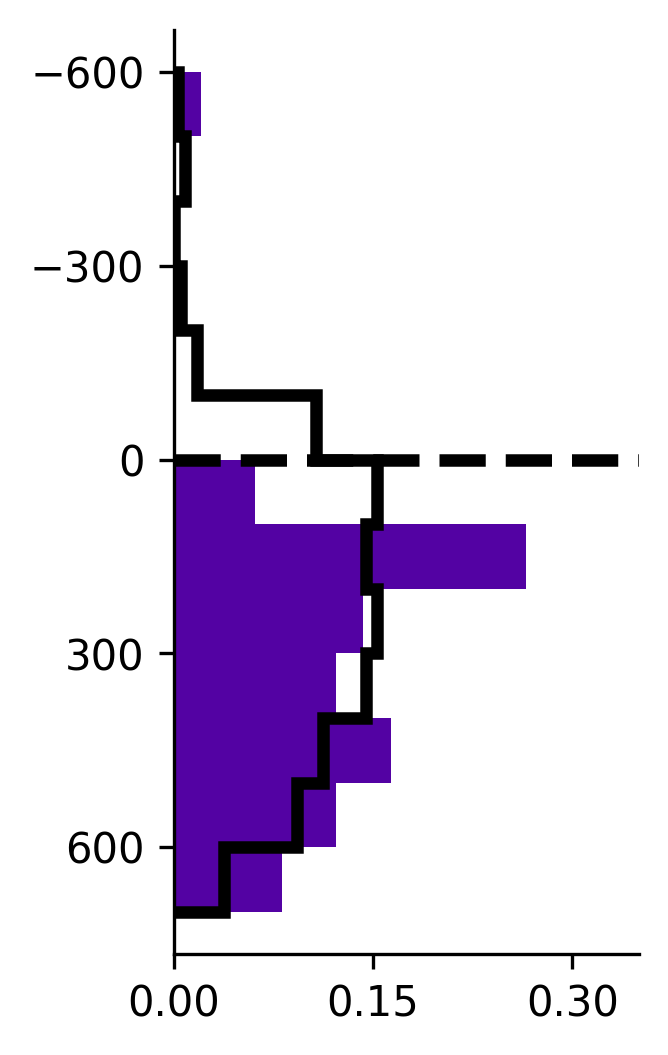

In [30]:
bins = np.arange(-600,800,100)
plasma_map = plt.cm.plasma(np.linspace(0,1,15))
clr = [plasma_map[12, :], plasma_map[5,:], plasma_map[8, :], plasma_map[10, :],plasma_map[2, :]]

fig, axs=plt.subplots(1,1,figsize=(2,4), dpi=300)
#axs = axs.ravel()
DepthFromL5 = DOI_Data.loc[:,'Wn_depth_from_layer5']
DepthFromL5 = DepthFromL5[PreDOI_Responsive.astype(bool)]
PreDOI_Labels_Lim = PreDOI_Labels[PreDOI_Responsive.astype(bool)]
tt = 4

weights = np.ones_like(DepthFromL5[PreDOI_Labels_Lim==tt])/float(len(DepthFromL5[PreDOI_Labels_Lim==tt]))
weights_all = np.ones_like(DepthFromL5)/float(len(DepthFromL5))
plt.hist(DepthFromL5[PreDOI_Labels_Lim==tt],bins,weights=weights,orientation= 'horizontal',color = clr[tt],histtype='stepfilled')
plt.hist(DepthFromL5,bins,weights=weights_all,orientation= 'horizontal',color = 'black',histtype='step',linewidth=3)
plt.axhline(0,color = 'black',linestyle='--',linewidth=3)
plt.gca().invert_yaxis()
plt.xlim(0,.35)
plt.xticks([0,.15,.3])
plt.yticks([600,300,0,-300,-600])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

if tt == 1:
    fig.savefig(os.path.join(figpath, 'Biphasic Laminar Location Histogram.eps'), dpi=300)
elif tt == 2:
        fig.savefig(os.path.join(figpath, 'Late Laminar Location Histogram.eps'), dpi=300)
elif tt == 3:
        fig.savefig(os.path.join(figpath, 'Early Laminar Location Histogram.eps'), dpi=300)
elif tt == 4:
        fig.savefig(os.path.join(figpath, 'Negative Laminar Location Histogram.eps'), dpi=300)

124
467


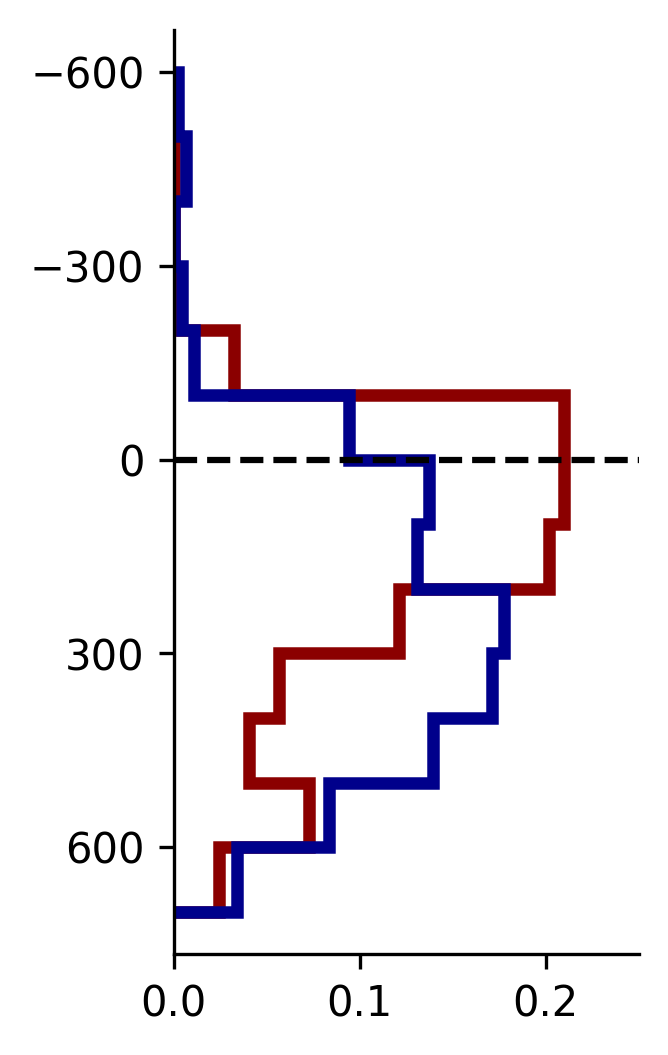

In [22]:
bins = np.arange(-600,800,100)

baselineInc_data = DepthFromL5[DOI_Change_Baseline_ModIDX>0]
baselineInc_data_counts = np.ones(len(baselineInc_data))/len(baselineInc_data)
print(len(baselineInc_data))
baselineDec_data = DepthFromL5[DOI_Change_Baseline_ModIDX<0]
baselineDec_data_counts = np.ones(len(baselineDec_data))/len(baselineDec_data)
print(len(baselineDec_data))

fig, axs=plt.subplots(1,1,figsize=(2,4), dpi=300)
plt.hist(baselineInc_data,bins,weights=baselineInc_data_counts,orientation= 'horizontal',histtype='step',linewidth=3,color ='darkred')
plt.hist(baselineDec_data,bins,weights=baselineDec_data_counts,orientation= 'horizontal',histtype='step',linewidth=3,color = 'darkblue')
plt.axhline(0,color = 'black',linestyle='--')
plt.gca().invert_yaxis()
plt.xlim(0,.25)
plt.xticks([0,.1,.2])
plt.yticks([600,300,0,-300,-600])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath, 'Binary DOI Change in Baseline Laminar Location Histogram.eps'), dpi=300)


32
467


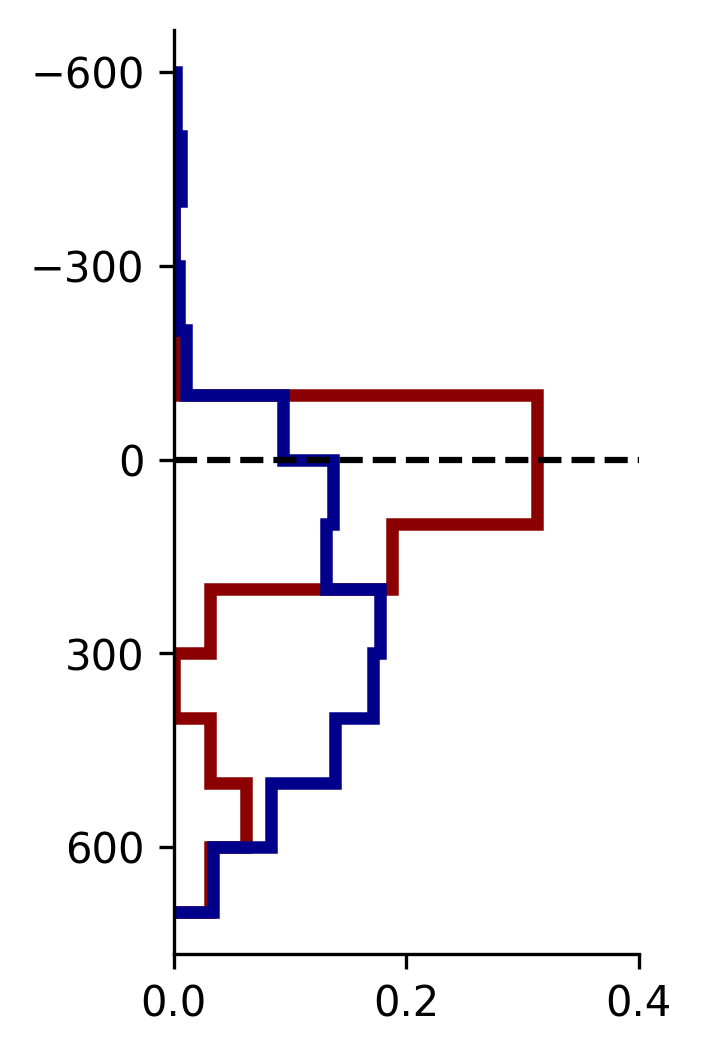

In [14]:
bins = np.arange(-600,800,100)

PreDOI_Labels_Lim = PreDOI_Labels[PreDOI_Responsive.astype(bool)]

tt = 1

baselineInc_data = DepthFromL5[(DOI_Change_Baseline>0) & (PreDOI_Labels_Lim==tt)]
baselineInc_data_counts = np.ones(len(baselineInc_data))/len(baselineInc_data)
print(len(baselineInc_data))
baselineDec_data = DepthFromL5[DOI_Change_Baseline<0 & (PreDOI_Labels_Lim==tt)]
baselineDec_data_counts = np.ones(len(baselineDec_data))/len(baselineDec_data)
print(len(baselineDec_data))

fig, axs=plt.subplots(1,1,figsize=(2,4), dpi=300)
plt.hist(baselineInc_data,bins,weights=baselineInc_data_counts,orientation= 'horizontal',histtype='step',linewidth=3,color ='darkred')
plt.hist(baselineDec_data,bins,weights=baselineDec_data_counts,orientation= 'horizontal',histtype='step',linewidth=3,color = 'darkblue')
plt.axhline(0,color = 'black',linestyle='--')
plt.gca().invert_yaxis()
plt.xlim(0,.35)
plt.xticks([0,.2,.4])
plt.yticks([600,300,0,-300,-600])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)


126
465


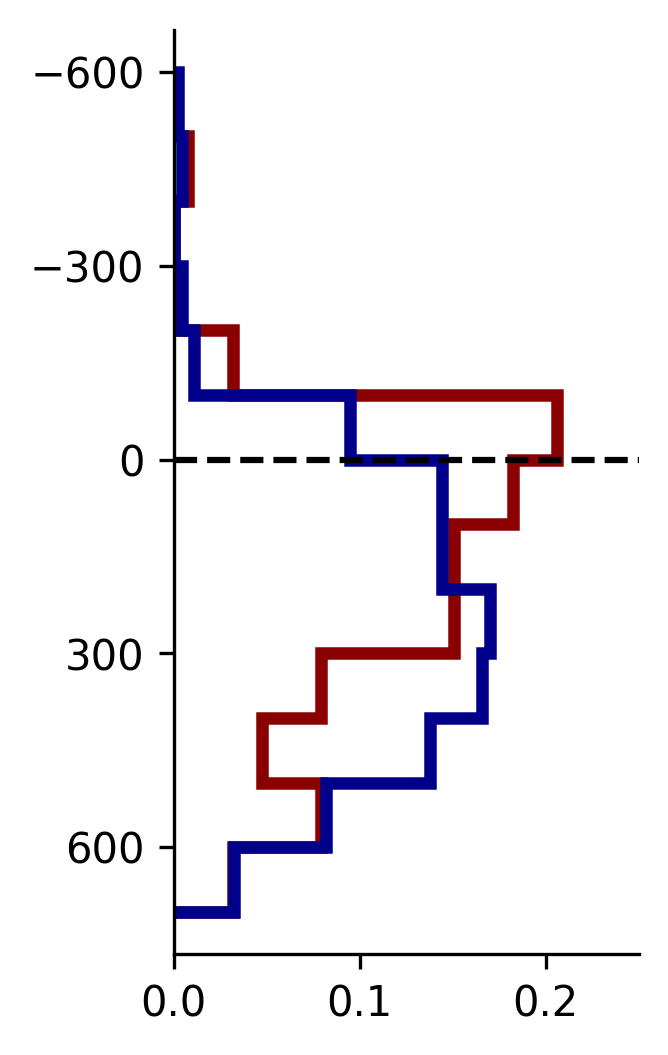

In [21]:
bins = np.arange(-600,800,100)

baselineInc_data = DepthFromL5[DOI_Change_Max_ModIDX>0]
baselineInc_data_counts = np.ones(len(baselineInc_data))/len(baselineInc_data)
print(len(baselineInc_data))
baselineDec_data = DepthFromL5[DOI_Change_Max_ModIDX<0]
baselineDec_data_counts = np.ones(len(baselineDec_data))/len(baselineDec_data)
print(len(baselineDec_data))

fig, axs=plt.subplots(1,1,figsize=(2,4), dpi=300)
plt.hist(baselineInc_data,bins,weights=baselineInc_data_counts,orientation= 'horizontal',histtype='step',linewidth=3,color ='darkred')
plt.hist(baselineDec_data,bins,weights=baselineDec_data_counts,orientation= 'horizontal',histtype='step',linewidth=3,color = 'darkblue')
#plt.hist(DepthFromL5,bins,weights=weights_all,orientation= 'horizontal',color = 'black',histtype='step',linewidth=3)
plt.axhline(0,color = 'black',linestyle='--')
plt.gca().invert_yaxis()
plt.xlim(0,.25)
plt.xticks([0,.1,.2])
plt.yticks([600,300,0,-300,-600])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

fig.savefig(os.path.join(figpath, 'Binary DOI Change in Max Laminar Location Histogram.eps'), dpi=300)


18
258


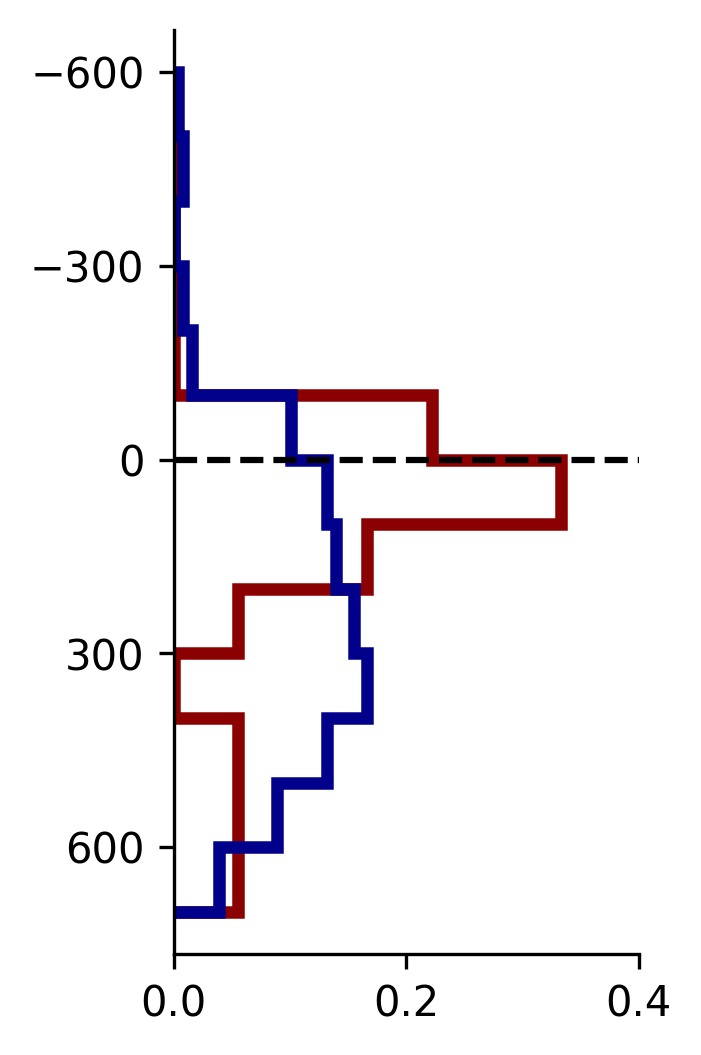

In [53]:
bins = np.arange(-600,800,100)

PreDOI_Labels_Lim = PreDOI_Labels[PreDOI_Responsive.astype(bool)]

tt = 1

baselineInc_data = DepthFromL5[(DOI_Change_Max>0) & (PreDOI_Labels_Lim==tt)]
baselineInc_data_counts = np.ones(len(baselineInc_data))/len(baselineInc_data)
print(len(baselineInc_data))
baselineDec_data = DepthFromL5[DOI_Change_Max<0 & (PreDOI_Labels_Lim==tt)]
baselineDec_data_counts = np.ones(len(baselineDec_data))/len(baselineDec_data)
print(len(baselineDec_data))

fig, axs=plt.subplots(1,1,figsize=(2,4), dpi=300)
plt.hist(baselineInc_data,bins,weights=baselineInc_data_counts,orientation= 'horizontal',histtype='step',linewidth=3,color ='darkred')
plt.hist(baselineDec_data,bins,weights=baselineDec_data_counts,orientation= 'horizontal',histtype='step',linewidth=3,color = 'darkblue')
plt.axhline(0,color = 'black',linestyle='--')
plt.gca().invert_yaxis()
plt.xlim(0,.35)
plt.xticks([0,.2,.4])
plt.yticks([600,300,0,-300,-600])
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

([<matplotlib.axis.XTick at 0x22345df6040>,
 [Text(0, 0, '0'), Text(15, 0, '15'), Text(30, 0, '30'), Text(45, 0, '45')])

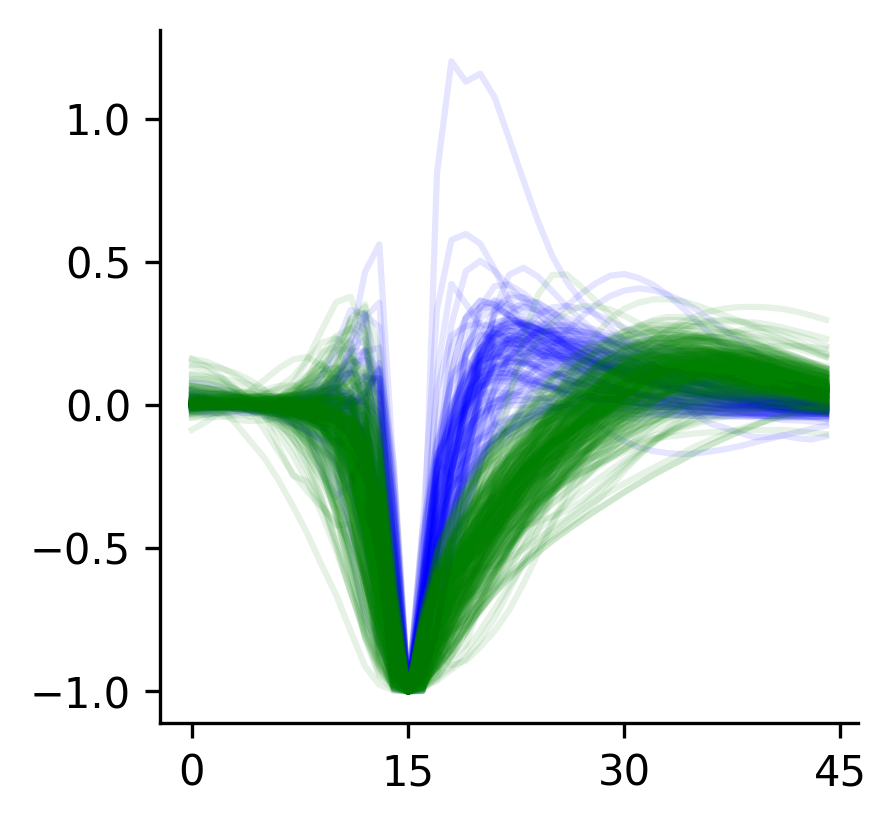

In [7]:
WaveformType = np.stack(DOI_Data.loc[:,'Waveform_Cluster'])
Waveforms = np.stack(DOI_Data.loc[:,'Waveform'])

WaveformType = WaveformType[PreDOI_Responsive.astype(bool)]
Waveforms = Waveforms[PreDOI_Responsive.astype(bool)]

#this waveform looks weird
Waveforms[127] = np.nan
#Waveforms[230]


fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)
plt.plot(Waveforms[WaveformType.astype(bool)].T,color = 'blue',label='inhibitory',alpha=.1)
plt.plot(Waveforms[~WaveformType.astype(bool)].T,color = 'green',label='excitatory',alpha=.1)

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.xticks(ticks = [0,15,30,45])
#fig.savefig(os.path.join(figpath,'DOI_Waveform_Clusters.eps'),dpi=300)

In [66]:
Biphasic_WaveTypes = [np.sum((WaveformType == 1) & (PreDOI_Labels_Lim == 3)), np.sum((WaveformType == 0) & (PreDOI_Labels_Lim == 3))]/ np.sum((PreDOI_Labels_Lim == 3))
Late_WaveTypes = [np.sum((WaveformType == 1) & (PreDOI_Labels_Lim == 2)), np.sum((WaveformType == 0) & (PreDOI_Labels_Lim == 2))]/ np.sum((PreDOI_Labels_Lim == 2))
Early_WaveTypes = [np.sum((WaveformType == 1) & (PreDOI_Labels_Lim == 1)), np.sum((WaveformType == 0) & (PreDOI_Labels_Lim == 1))]/ np.sum((PreDOI_Labels_Lim == 1))
Negative_WaveTypes = [np.sum((WaveformType == 1) & (PreDOI_Labels_Lim == 4)), np.sum((WaveformType == 0) & (PreDOI_Labels_Lim == 4))]/ np.sum((PreDOI_Labels_Lim == 4))

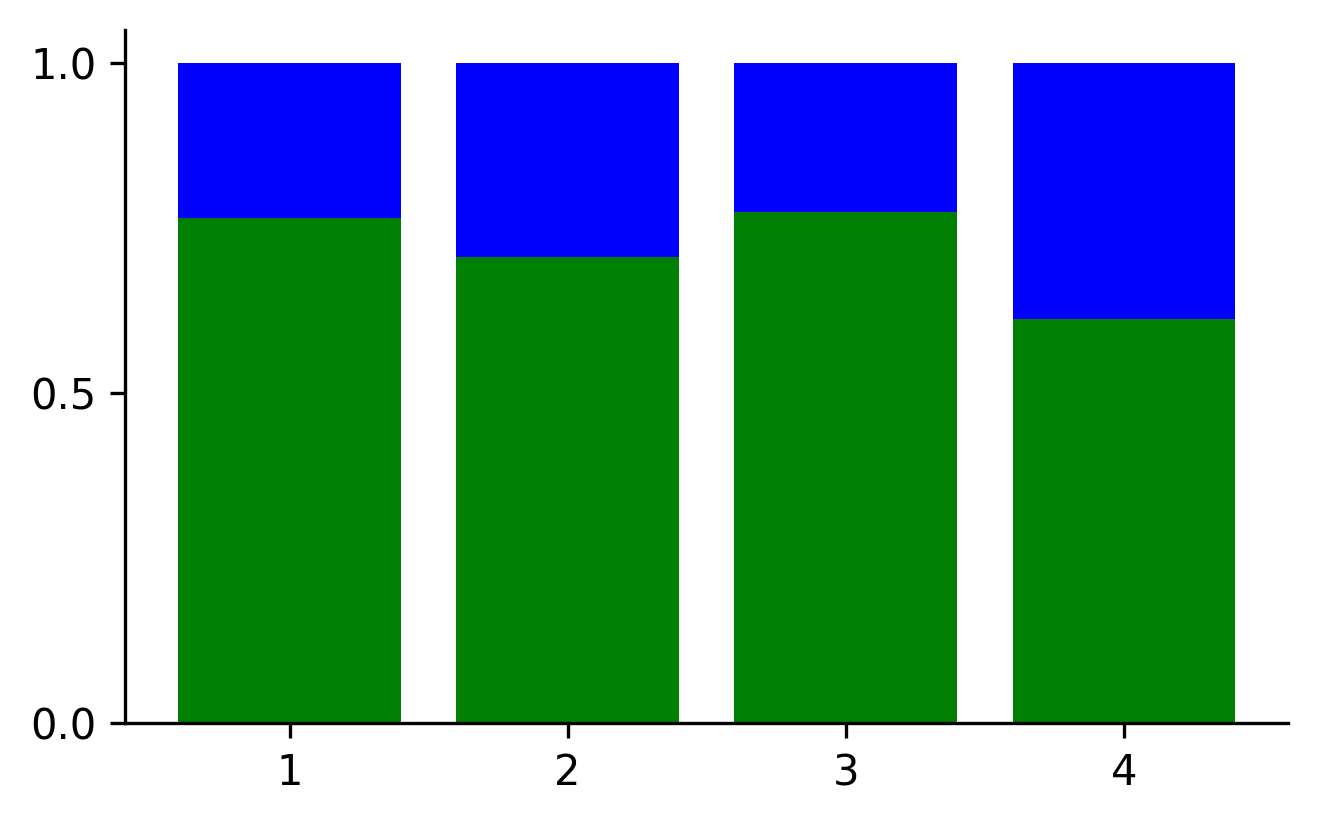

In [67]:
fig, axs=plt.subplots(1,1,figsize=(5,3), dpi=300)

plt.bar(1,Early_WaveTypes[1],color = 'green')
plt.bar(1,Early_WaveTypes[0],bottom=Early_WaveTypes[1],color = 'blue')
plt.bar(2,Late_WaveTypes[1],color = 'green')
plt.bar(2,Late_WaveTypes[0],bottom=Late_WaveTypes[1],color = 'blue')
plt.bar(3,Biphasic_WaveTypes[1],color = 'green')
plt.bar(3,Biphasic_WaveTypes[0],bottom=Biphasic_WaveTypes[1],color = 'blue')
plt.bar(4,Negative_WaveTypes[1],color = 'green')
plt.bar(4,Negative_WaveTypes[0],bottom=Negative_WaveTypes[1],color = 'blue')

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.xticks([1,2,3,4])
plt.yticks([0.,.5,1])
fig.savefig(os.path.join(figpath,'DOI_Waveform_Clusters_byGazeType.eps'),dpi=300)

In [15]:
import scipy.interpolate
import scipy.signal

1.6118970439271665 t - early
0.10698434557501069 p - early


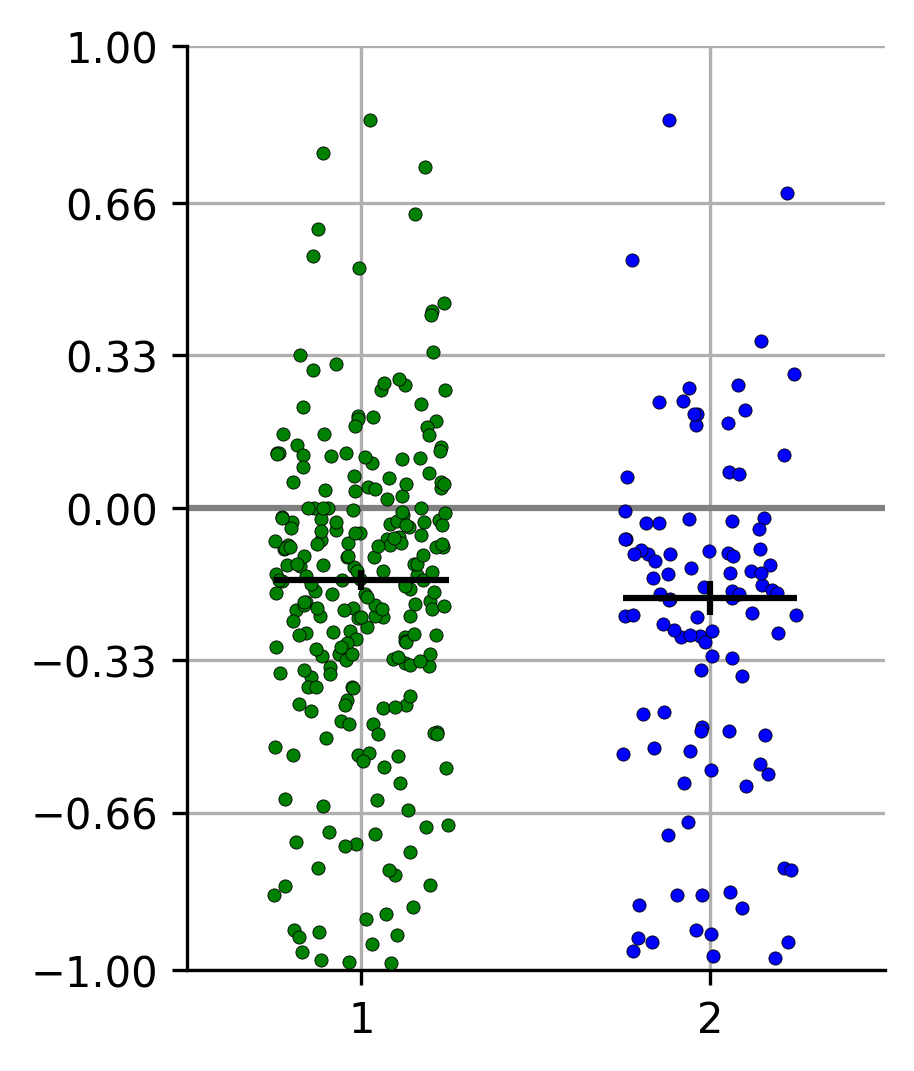

In [27]:
fig, axs=plt.subplots(1,1,figsize=(3,4), dpi=300)
plt.scatter(jitter(0,np.sum(WaveformType==0)), DOI_Change_Max_ModIDX[WaveformType==0], color = 'green', s=10,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.errorbar(1,np.nanmedian(DOI_Change_Max_ModIDX[WaveformType==0]),xerr = .25, yerr = np.nanstd(DOI_Change_Max_ModIDX[WaveformType==0])/np.sqrt(sum(WaveformType==0)),color = 'black', linewidth = 1.5,zorder = 8)
plt.scatter(jitter(1,np.sum(WaveformType==1)), DOI_Change_Max_ModIDX[WaveformType==1], color = 'blue', s=10,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.errorbar(2,np.nanmedian(DOI_Change_Max_ModIDX[WaveformType==1]),xerr = .25, yerr = np.nanstd(DOI_Change_Max_ModIDX[WaveformType==1])/np.sqrt(sum(WaveformType==1)),color = 'black', linewidth = 1.5,zorder = 8)
plt.grid(zorder = 8)
plt.xlim(.5,2.5)
plt.xticks(ticks= [1,2])
plt.ylim(-1,1)
plt.yticks(ticks= [-1,-.66,-.33,0,.33,.66,1])
#plt.ylim(-25,21)
#plt.yticks(ticks= [-20,-10,0,10,20])
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.axhline(0,linestyle='-',color = 'grey')
plt.gca().set_rasterized(True)

DOI_Change_Max_ModIDX = np.nan_to_num(DOI_Change_Max_ModIDX)

from scipy import stats
t_stat, p_value = stats.ranksums(DOI_Change_Max_ModIDX[WaveformType==0],DOI_Change_Max_ModIDX[WaveformType==1])
print(t_stat, 't - early')
print(p_value, 'p - early')



fig.savefig(os.path.join(figpath,'DOI_ChangeFR_NarrowWideSpiking.eps'),dpi=300)

1.6118970439271665 t - 
0.10698434557501069 p - 


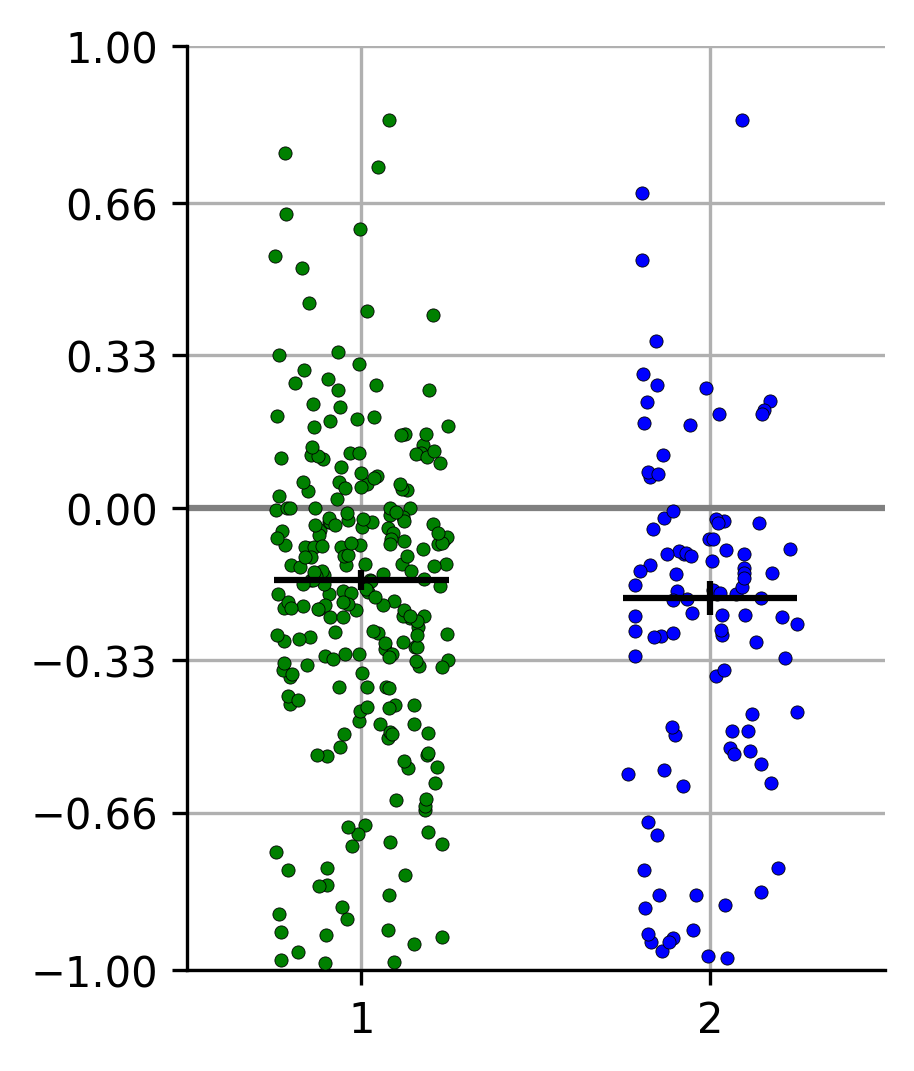

In [26]:
fig, axs=plt.subplots(1,1,figsize=(3,4), dpi=300)
plt.scatter(jitter(0,np.sum(WaveformType==0)), DOI_Change_Baseline_ModIDX[WaveformType==0], color = 'green', s=10,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.errorbar(1,np.nanmedian(DOI_Change_Baseline_ModIDX[WaveformType==0]),xerr = .25, yerr = np.nanstd(DOI_Change_Baseline_ModIDX[WaveformType==0])/np.sqrt(sum(WaveformType==0)),color = 'black', linewidth = 1.5,zorder = 8)
plt.scatter(jitter(1,np.sum(WaveformType==1)), DOI_Change_Baseline_ModIDX[WaveformType==1], color = 'blue', s=10,zorder = 7,edgecolor = 'black',linewidth=.2)
plt.errorbar(2,np.nanmedian(DOI_Change_Baseline_ModIDX[WaveformType==1]),xerr = .25, yerr = np.nanstd(DOI_Change_Baseline_ModIDX[WaveformType==1])/np.sqrt(sum(WaveformType==1)),color = 'black', linewidth = 1.5,zorder = 8)
plt.grid(zorder = 8)
plt.xlim(.5,2.5)
plt.xticks(ticks= [1,2])
#plt.ylim(-25,21)
plt.ylim(-1,1)
plt.yticks(ticks= [-1,-.66,-.33,0,.33,.66,1])
#plt.yticks(ticks= [-20,-10,0,10,20])
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.axhline(0,linestyle='-',color = 'grey')
plt.gca().set_rasterized(True)

DOI_Change_Baseline_ModIDX = np.nan_to_num(DOI_Change_Baseline_ModIDX)
from scipy import stats
t_stat, p_value = stats.ranksums(DOI_Change_Baseline_ModIDX[WaveformType==0],DOI_Change_Baseline_ModIDX[WaveformType==1])
print(t_stat, 't - ')
print(p_value, 'p - ')

fig.savefig(os.path.join(figpath,'DOI_ChangeBaseline_NarrowWideSpiking.eps'),dpi=300)

In [65]:
DOI_BaselineChange_Increasers = DOI_Change_Baseline.copy()
np.nan_to_num(DOI_BaselineChange_Increasers)
DOI_BaselineChange_Increasers[DOI_BaselineChange_Increasers<=0] = 0
DOI_BaselineChange_Increasers[DOI_BaselineChange_Increasers>0] = 1

DOI_BaselineChange_Decreasers = DOI_Change_Baseline.copy()
np.nan_to_num(DOI_BaselineChange_Decreasers)
DOI_BaselineChange_Decreasers[DOI_BaselineChange_Decreasers>=0] = 0
DOI_BaselineChange_Decreasers[DOI_BaselineChange_Decreasers<0] = 1

Excitatory_Baseline_Increasers = np.argwhere((WaveformType==0) & (DOI_BaselineChange_Increasers== 1))
Excitatory_Baseline_Decreasers = np.argwhere((WaveformType==0) & (DOI_BaselineChange_Decreasers== 1))

Inhibitory_Baseline_Increasers = np.argwhere((WaveformType==1) & (DOI_BaselineChange_Increasers== 1))
Inhibitory_Baseline_Decreasers = np.argwhere((WaveformType==1) & (DOI_BaselineChange_Decreasers== 1))

In [66]:
print(len(Excitatory_Baseline_Decreasers)/np.sum(WaveformType==0))
print(len(Excitatory_Baseline_Increasers)/np.sum(WaveformType==0))
print(len(Excitatory_Baseline_Decreasers)/np.sum(WaveformType==0) + len(Excitatory_Baseline_Increasers)/np.sum(WaveformType==0))

print(len(Inhibitory_Baseline_Decreasers)/np.sum(WaveformType==1))
print(len(Inhibitory_Baseline_Increasers)/np.sum(WaveformType==1))
print(len(Inhibitory_Baseline_Decreasers)/np.sum(WaveformType==1) + len(Inhibitory_Baseline_Increasers)/np.sum(WaveformType==1))

0.7510204081632653
0.24081632653061225
0.9918367346938776
0.8217821782178217
0.1782178217821782
1.0


In [67]:
Excitatory_Baseline_Decreaser_Percentage = np.round(len(Excitatory_Baseline_Decreasers)/np.sum(WaveformType==0),2)
Excitatory_Baseline_Increaser_Percentage = np.round(len(Excitatory_Baseline_Increasers)/np.sum(WaveformType==0),2)

print(Excitatory_Baseline_Decreaser_Percentage)
print(Excitatory_Baseline_Increaser_Percentage)

0.75
0.24


([<matplotlib.axis.YTick at 0x1c7d9af3eb0>,
 [Text(0, 0.0, '0.0'), Text(0, 0.5, '0.5'), Text(0, 1.0, '1.0')])

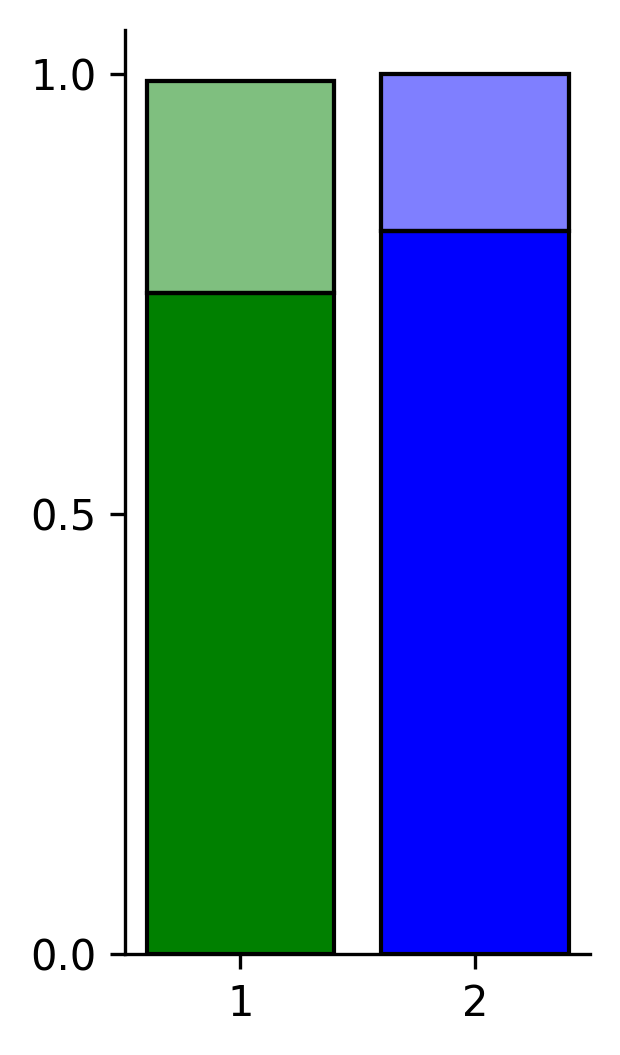

In [58]:
fig, axs=plt.subplots(1,1,figsize=(2,4), dpi=300)

plt.bar(1,len(Excitatory_Baseline_Decreasers)/np.sum(WaveformType==0),color = 'green',edgecolor = 'black',zorder = 5)
plt.bar(1,len(Excitatory_Baseline_Increasers)/np.sum(WaveformType==0),bottom=len(Excitatory_Baseline_Decreasers)/np.sum(WaveformType==0),color = 'green',edgecolor = 'black',alpha=.5,zorder = 5)
plt.bar(1,len(Excitatory_Baseline_Increasers)/np.sum(WaveformType==0),bottom=len(Excitatory_Baseline_Decreasers)/np.sum(WaveformType==0),color = "none",edgecolor = 'black', zorder = 5)

plt.bar(2,len(Inhibitory_Baseline_Decreasers)/np.sum(WaveformType==1),color = 'blue',edgecolor = 'black',zorder = 5)
plt.bar(2,len(Inhibitory_Baseline_Increasers)/np.sum(WaveformType==1),bottom=len(Inhibitory_Baseline_Decreasers)/np.sum(WaveformType==1),color = 'blue',edgecolor = 'black',alpha=.5,zorder = 5)
plt.bar(2,len(Inhibitory_Baseline_Increasers)/np.sum(WaveformType==1),bottom=len(Inhibitory_Baseline_Decreasers)/np.sum(WaveformType==1),color = "none",edgecolor = 'black', zorder = 5)

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.xticks([1,2])
plt.yticks([0.,.5,1])
#fig.savefig(os.path.join(figpath,'DOI_Waveform_Clusters_byGazeType.eps'),dpi=300)